In [ ]:
print("📦 Installing required packages...")
!pip install pandas scikit-learn matplotlib seaborn xgboost lightgbm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import shutil
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("✅ All packages installed and imported!")
print("🐝 Varroa Detection using Environmental Sensors")
print("🌡️ Temperature, Humidity, CO2 Analysis")
print("=" * 60)

📦 Installing required packages...
✅ All packages installed and imported!
🐝 Varroa Detection using Environmental Sensors
🌡️ Temperature, Humidity, CO2 Analysis


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Clean up any existing data
if os.path.exists('./varroa_sensor_data'):
    shutil.rmtree('./varroa_sensor_data')
    print("🧹 Cleaned up old dataset")

# Your sensor dataset ZIP file in Drive
sensor_zip = "/content/drive/MyDrive/varroa_sensor_data.zip"  # UPDATE THIS NAME

print(f"📁 Looking for sensor dataset: {sensor_zip}")

if os.path.exists(sensor_zip):
    print("✅ Found sensor dataset in Google Drive!")
    print(f"📊 Size: {os.path.getsize(sensor_zip) / 1e6:.1f} MB")

    print("📦 Extracting sensor data...")
    with zipfile.ZipFile(sensor_zip, 'r') as zip_ref:
        zip_ref.extractall('./varroa_sensor_data')

    print("✅ Sensor dataset extraction complete!")

    # Show dataset structure
    print("\n📁 Dataset structure:")
    for root, dirs, files in os.walk('./varroa_sensor_data'):
        level = root.replace('./varroa_sensor_data', '').count(os.sep)
        indent = ' ' * 2 * level
        if level == 0:
            print(f"{indent}📁 {os.path.basename(root) or 'varroa_sensor_data'}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files:
            if file.endswith('.csv'):
                size_mb = os.path.getsize(os.path.join(root, file)) / 1e6
                print(f"{subindent}📄 {file} ({size_mb:.1f} MB)")

else:
    print(f"❌ Sensor dataset not found at: {sensor_zip}")
    print("Please upload your sensor data ZIP file to Google Drive")
    print("💡 Expected: CSV files with temperature, humidity, CO2 data")

Mounted at /content/drive
📁 Looking for sensor dataset: /content/drive/MyDrive/varroa_sensor_data.zip
✅ Found sensor dataset in Google Drive!
📊 Size: 0.7 MB
📦 Extracting sensor data...
✅ Sensor dataset extraction complete!

📁 Dataset structure:
📁 varroa_sensor_data/
  📄 hive_monitoring_dataset.csv (0.7 MB)
  📄 data_Varroa_Detection.csv (1.0 MB)


In [ ]:
def load_and_process_sensor_data():
    """Load sensor data and translate column names"""
    print("🔄 LOADING AND PROCESSING SENSOR DATA")
    print("=" * 45)

    # Find CSV files
    csv_files = []
    for root, dirs, files in os.walk('./varroa_sensor_data'):
        for file in files:
            if file.lower().endswith('.csv'):
                csv_files.append(os.path.join(root, file))

    if not csv_files:
        print("❌ No CSV files found!")
        return None, None, None

    print(f"📄 Found {len(csv_files)} CSV file(s)")

    # Load and combine datasets
    all_data = []
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            print(f"   📊 {os.path.basename(csv_file)}: {len(df)} rows, {len(df.columns)} columns")
            all_data.append(df)
        except Exception as e:
            print(f"   ❌ Error loading {os.path.basename(csv_file)}: {e}")

    if not all_data:
        return None, None, None

    # Use the largest dataset or combine if similar structure
    main_df = max(all_data, key=len)
    print(f"\n📊 Using dataset with {len(main_df)} rows")
    print(f"📝 Original columns: {list(main_df.columns)}")

    # Translate column names from any language to English
    column_translation = {
        'Promedio Temperatura': 'temperature',
        'Promedio Humedad': 'humidity',
        'Promedio CO2': 'co2',
        'Promedio TVCO': 'tvco',
        'Suma de Pesos': 'weight',
        'Suma': 'total',
        'Nivel de Alerta General': 'alert_level',
        'Alerta predicha': 'predicted_alert',
        # Add other possible translations
        'temperatura': 'temperature',
        'humedad': 'humidity',
        'temp': 'temperature',
        'humid': 'humidity',
        'carbon': 'co2'
    }

    # Apply translations
    df = main_df.copy()
    for old_name, new_name in column_translation.items():
        if old_name in df.columns:
            df = df.rename(columns={old_name: new_name})

    print(f"📝 Translated columns: {list(df.columns)}")

    # Identify sensor columns and target
    sensor_cols = []
    target_col = None

    for col in df.columns:
        col_lower = col.lower()
        if 'temp' in col_lower:
            sensor_cols.append(col)
            print(f"   🌡️ Temperature: {col}")
        elif 'humid' in col_lower:
            sensor_cols.append(col)
            print(f"   💧 Humidity: {col}")
        elif 'co2' in col_lower:
            sensor_cols.append(col)
            print(f"   🌬️ CO2: {col}")
        elif any(word in col_lower for word in ['alert', 'level', 'varroa', 'mite']):
            target_col = col
            print(f"   🎯 Target: {col}")
        elif col_lower in ['tvco', 'weight', 'total']:
            sensor_cols.append(col)
            print(f"   📊 Additional sensor: {col}")

    if not target_col:
        print("❌ No target column found!")
        return None, None, None

    # Analyze target distribution
    print(f"\n🎯 Target Distribution ({target_col}):")
    target_dist = df[target_col].value_counts()
    for val, count in target_dist.items():
        print(f"   {val}: {count} ({count/len(df)*100:.1f}%)")

    # Basic statistics
    print(f"\n📈 Sensor Statistics:")
    if sensor_cols:
        stats = df[sensor_cols].describe()
        print(stats)

    # Check missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\n⚠️ Missing Values:")
        for col, miss in missing[missing > 0].items():
            print(f"   {col}: {miss}")
        # Fill missing values
        for col in sensor_cols + [target_col]:
            if df[col].isnull().sum() > 0:
                if df[col].dtype in ['object', 'category']:
                    df[col].fillna(df[col].mode()[0], inplace=True)
                else:
                    df[col].fillna(df[col].median(), inplace=True)
        print("✅ Missing values filled")

    return df, sensor_cols, target_col

# Load and process data
df, sensor_columns, target_column = load_and_process_sensor_data()

🔄 LOADING AND PROCESSING SENSOR DATA
📄 Found 2 CSV file(s)
   📊 hive_monitoring_dataset.csv: 10000 rows, 6 columns
   📊 data_Varroa_Detection.csv: 10000 rows, 6 columns

📊 Using dataset with 10000 rows
📝 Original columns: ['Promedio Temperatura', 'Promedio Humedad', 'Promedio CO2', 'Promedio TVCO', 'Suma de Pesos', 'Nivel de Alerta General']
📝 Translated columns: ['temperature', 'humidity', 'co2', 'tvco', 'weight', 'alert_level']
   🌡️ Temperature: temperature
   💧 Humidity: humidity
   🌬️ CO2: co2
   📊 Additional sensor: tvco
   📊 Additional sensor: weight
   🎯 Target: alert_level

🎯 Target Distribution (alert_level):
   Alto: 4867 (48.7%)
   Muy Alto: 2481 (24.8%)
   Medio: 2424 (24.2%)
   Bajo: 228 (2.3%)

📈 Sensor Statistics:
        temperature      humidity           co2          tvco        weight
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean      28.535468     60.065726   1702.986800   1241.572000      0.499093
std        4.924550     14.47647

In [ ]:
# ===== CELL 3.5: Translate CSV Files to English =====
def translate_csv_files():
    """Translate Spanish CSV files to English and save them"""
    print("🔄 TRANSLATING CSV FILES TO ENGLISH")
    print("=" * 40)

    # Translation mapping
    column_translation = {
        'Promedio Temperatura': 'avg_temperature',
        'Promedio Humedad': 'avg_humidity',
        'Promedio CO2': 'avg_co2',
        'Promedio TVCO': 'avg_tvco',
        'Suma de Pesos': 'total_weight',
        'Suma': 'total_sum',
        'Nivel de Alerta General': 'alert_level',
        'Alerta predicha': 'predicted_alert'
    }

    # Value translation for target column
    value_translation = {
        'Alto': 'High',
        'Bajo': 'Low',
        'Medio': 'Medium',
        'Muy Alto': 'Very High'
    }

    # Find and translate all CSV files
    csv_files = []
    for root, dirs, files in os.walk('./varroa_sensor_data'):
        for file in files:
            if file.lower().endswith('.csv'):
                csv_files.append(os.path.join(root, file))

    for csv_file in csv_files:
        try:
            # Load CSV
            df = pd.read_csv(csv_file)
            original_name = os.path.basename(csv_file)

            # Translate columns
            df_translated = df.rename(columns=column_translation)

            # Translate target values if they exist
            for col in df_translated.columns:
                if 'alert' in col.lower() or 'level' in col.lower():
                    df_translated[col] = df_translated[col].replace(value_translation)

            # Save translated file
            english_name = original_name.replace('.csv', '_english.csv')
            english_path = os.path.join('./varroa_sensor_data', english_name)
            df_translated.to_csv(english_path, index=False)

            print(f"✅ Translated: {original_name} → {english_name}")
            print(f"   Columns: {list(df_translated.columns)}")

        except Exception as e:
            print(f"❌ Error translating {original_name}: {e}")

    print("✅ All CSV files translated to English!")

# Run translation
translate_csv_files()

🔄 TRANSLATING CSV FILES TO ENGLISH
✅ Translated: hive_monitoring_dataset.csv → hive_monitoring_dataset_english.csv
   Columns: ['avg_temperature', 'avg_humidity', 'avg_co2', 'avg_tvco', 'total_weight', 'alert_level']
✅ Translated: data_Varroa_Detection.csv → data_Varroa_Detection_english.csv
   Columns: ['avg_temperature', 'avg_humidity', 'avg_co2', 'avg_tvco', 'total_sum', 'predicted_alert']
✅ All CSV files translated to English!


In [ ]:
def engineer_features_and_train(df, sensor_cols, target_col):
    """Engineer features and train varroa detection models"""
    print("🔧 FEATURE ENGINEERING AND MODEL TRAINING")
    print("=" * 50)

    if df is None:
        print(" No data available")
        return None

    # Create feature matrix
    X = df[sensor_cols].copy()
    y = df[target_col]

    print(f"📊 Base features: {len(sensor_cols)}")

    # Feature engineering for environmental sensors
    new_features = []

    # Temperature features
    if 'temperature' in X.columns:
        X['temp_stress'] = ((X['temperature'] < 32) | (X['temperature'] > 36)).astype(int)
        X['temp_optimal_deviation'] = np.minimum(
            np.abs(X['temperature'] - 32),
            np.abs(X['temperature'] - 36)
        )
        new_features.extend(['temp_stress', 'temp_optimal_deviation'])

    # Humidity features
    if 'humidity' in X.columns:
        X['humidity_stress'] = ((X['humidity'] < 50) | (X['humidity'] > 70)).astype(int)
        X['humidity_optimal_deviation'] = np.minimum(
            np.abs(X['humidity'] - 50),
            np.abs(X['humidity'] - 70)
        )
        new_features.extend(['humidity_stress', 'humidity_optimal_deviation'])

    # CO2 features
    if 'co2' in X.columns:
        X['co2_stress'] = (X['co2'] > 1000).astype(int)
        X['co2_excess'] = np.maximum(0, X['co2'] - 400)
        new_features.extend(['co2_stress', 'co2_excess'])

    # Combined features
    if 'temperature' in X.columns and 'humidity' in X.columns:
        X['heat_index'] = X['temperature'] + 0.5 * (X['humidity'] - 50)
        X['temp_humidity_ratio'] = X['temperature'] / (X['humidity'] + 1)
        new_features.extend(['heat_index', 'temp_humidity_ratio'])

    # Total stress score
    stress_features = [f for f in new_features if 'stress' in f]
    if stress_features:
        X['total_stress'] = X[stress_features].sum(axis=1)
        new_features.append('total_stress')

    print(f" Engineered features: {len(new_features)}")
    print(f" Total features: {len(X.columns)}")

    # Encode target if needed
    le = None
    if y.dtype == 'object':
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
        print(f" Target encoded: {dict(zip(le.classes_, range(len(le.classes_))))}")
    else:
        y_encoded = y

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )

    print(f"\n🏋️ Training models...")
    print(f"   Training: {len(X_train)} samples")
    print(f"   Testing: {len(X_test)} samples")

    # Models optimized for sensor data
    models = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=12, random_state=42, class_weight='balanced'
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42
        ),
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=200, max_depth=6, random_state=42, verbose=-1
        ),
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=42, class_weight='balanced'))
        ])
    }

    results = {}
    best_model = None
    best_score = 0

    for name, model in models.items():
        print(f"\n    Training {name}...")

        try:
            # Cross-validation
            cv_scores = cross_val_score(
                model, X_train, y_train,
                cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                scoring='accuracy'
            )

            # Fit and test
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            test_accuracy = accuracy_score(y_test, y_pred)

            results[name] = {
                'model': model,
                'cv_mean': cv_scores.mean(),
                'cv_std': cv_scores.std(),
                'test_accuracy': test_accuracy,
                'predictions': y_pred
            }

            print(f"      CV: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
            print(f"      Test: {test_accuracy:.4f}")

            if cv_scores.mean() > best_score:
                best_score = cv_scores.mean()
                best_model = name

        except Exception as e:
            print(f"       Failed: {e}")

    print(f"\n🏆 MODEL PERFORMANCE:")
    print("=" * 40)
    for name, result in sorted(results.items(), key=lambda x: x[1]['cv_mean'], reverse=True):
        print(f"{name:20} | CV: {result['cv_mean']:.4f} | Test: {result['test_accuracy']:.4f}")

    print(f"\n Best Model: {best_model}")
    print(f" Best Accuracy: {best_score:.4f}")

    return results, X_test, y_test, best_model, X.columns, le

# Train models
if df is not None:
    model_results, X_test, y_test, best_model_name, feature_columns, label_encoder = engineer_features_and_train(df, sensor_columns, target_column)

🔧 FEATURE ENGINEERING AND MODEL TRAINING
📊 Base features: 5
 Engineered features: 9
 Total features: 14
 Target encoded: {'Alto': 0, 'Bajo': 1, 'Medio': 2, 'Muy Alto': 3}

🏋️ Training models...
   Training: 8000 samples
   Testing: 2000 samples

    Training Random Forest...
      CV: 0.9998 (±0.0005)
      Test: 1.0000

    Training XGBoost...
      CV: 0.9960 (±0.0016)
      Test: 0.9960

    Training LightGBM...
      CV: 0.9963 (±0.0015)
      Test: 0.9965

    Training Logistic Regression...
      CV: 0.9824 (±0.0049)
      Test: 0.9820

🏆 MODEL PERFORMANCE:
Random Forest        | CV: 0.9998 | Test: 1.0000
LightGBM             | CV: 0.9963 | Test: 0.9965
XGBoost              | CV: 0.9960 | Test: 0.9960
Logistic Regression  | CV: 0.9824 | Test: 0.9820

 Best Model: Random Forest
 Best Accuracy: 0.9998


🔍 ANALYZING BEST MODEL: Random Forest
📊 Classification Report:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       973
        Bajo       1.00      1.00      1.00        46
       Medio       1.00      1.00      1.00       485
    Muy Alto       1.00      1.00      1.00       496

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



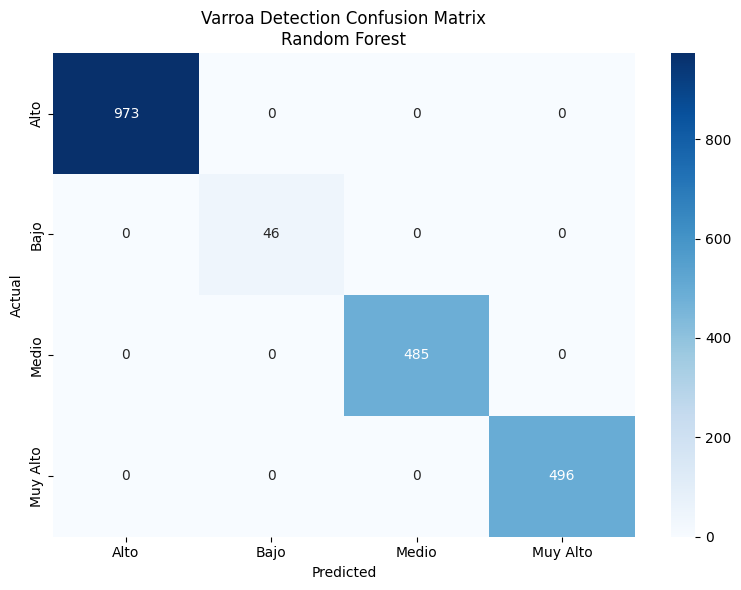


🔝 Top Environmental Factors:
               feature  importance
                weight    0.445571
           temperature    0.150348
   temp_humidity_ratio    0.117471
temp_optimal_deviation    0.092635
              humidity    0.050427
            co2_excess    0.027640
                   co2    0.027587
            heat_index    0.026085
                  tvco    0.023280
           temp_stress    0.015901


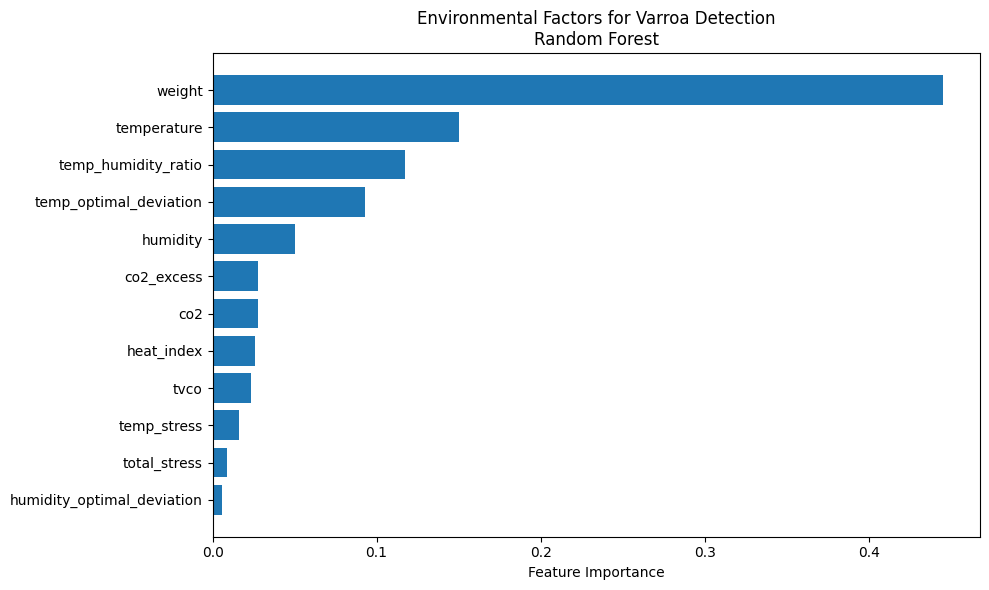

In [ ]:
if model_results and best_model_name:
    print(f"🔍 ANALYZING BEST MODEL: {best_model_name}")
    print("=" * 45)

    best_pipeline = model_results[best_model_name]['model']
    y_pred = model_results[best_model_name]['predictions']

    # Classification report
    target_names = label_encoder.classes_ if label_encoder else ['Normal', 'Varroa Detected']
    print("📊 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Varroa Detection Confusion Matrix\n{best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Feature importance
    if hasattr(best_pipeline, 'feature_importances_'):
        importances = best_pipeline.feature_importances_
    elif hasattr(best_pipeline, 'named_steps') and hasattr(best_pipeline.named_steps['classifier'], 'coef_'):
        importances = np.abs(best_pipeline.named_steps['classifier'].coef_[0])
    else:
        importances = None

    if importances is not None:
        print(f"\n🔝 Top Environmental Factors:")
        feature_importance = pd.DataFrame({
            'feature': feature_columns,
            'importance': importances
        }).sort_values('importance', ascending=False)

        print(feature_importance.head(10).to_string(index=False))

        # Plot feature importance
        plt.figure(figsize=(10, 6))
        top_features = feature_importance.head(12)
        plt.barh(range(len(top_features)), top_features['importance'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Feature Importance')
        plt.title(f'Environmental Factors for Varroa Detection\n{best_model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

In [ ]:
print("📦 CREATING RASPBERRY PI DEPLOYMENT PACKAGE")
print("=" * 50)

if model_results and best_model_name:
    import pickle

    # Save the best model using pickle protocol 4 for cross-version compatibility
    best_model = model_results[best_model_name]['model']
    with open('varroa_sensor_model.pkl', 'wb') as f:
        pickle.dump(best_model, f, protocol=4)
    print("✅ Saved: varroa_sensor_model.pkl")

    # Save label encoder
    if label_encoder:
        with open('varroa_label_encoder.pkl', 'wb') as f:
            pickle.dump(label_encoder, f, protocol=4)
        print("✅ Saved: varroa_label_encoder.pkl")

    # Create prediction script
    prediction_script = f'''#!/usr/bin/env python3
"""
Varroa Mite Detection using Environmental Sensors
Best Model: {best_model_name}
Accuracy: {model_results[best_model_name]['test_accuracy']:.4f}
"""

import pandas as pd
import numpy as np
import pickle

class VarroaSensorDetector:
    def __init__(self, model_path="varroa_sensor_model.pkl", encoder_path="varroa_label_encoder.pkl"):
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        try:
            with open(encoder_path, 'rb') as f:
                self.label_encoder = pickle.load(f)
        except:
            self.label_encoder = None

        self.feature_names = {list(feature_columns)}

    def predict_varroa(self, temperature=None, humidity=None, co2=None, **kwargs):
        """
        Predict varroa presence from sensor readings

        Args:
            temperature (float): Temperature in Celsius
            humidity (float): Humidity percentage
            co2 (float): CO2 in ppm
            **kwargs: Additional sensor values

        Returns:
            dict: Prediction with confidence
        """
        # Create base features
        features = {{}}
        if temperature is not None:
            features['temperature'] = temperature
        if humidity is not None:
            features['humidity'] = humidity
        if co2 is not None:
            features['co2'] = co2

        # Add any additional sensors
        for key, value in kwargs.items():
            if value is not None:
                features[key] = value

        # Engineer features (same as training)
        if temperature is not None:
            features['temp_stress'] = 1 if (temperature < 32 or temperature > 36) else 0
            features['temp_optimal_deviation'] = min(abs(temperature - 32), abs(temperature - 36))

        if humidity is not None:
            features['humidity_stress'] = 1 if (humidity < 50 or humidity > 70) else 0
            features['humidity_optimal_deviation'] = min(abs(humidity - 50), abs(humidity - 70))

        if co2 is not None:
            features['co2_stress'] = 1 if co2 > 1000 else 0
            features['co2_excess'] = max(0, co2 - 400)

        if temperature is not None and humidity is not None:
            features['heat_index'] = temperature + 0.5 * (humidity - 50)
            features['temp_humidity_ratio'] = temperature / (humidity + 1)

        # Calculate total stress
        stress_features = ['temp_stress', 'humidity_stress', 'co2_stress']
        features['total_stress'] = sum(features.get(f, 0) for f in stress_features)

        # Create feature vector
        feature_vector = []
        for feature_name in self.feature_names:
            feature_vector.append(features.get(feature_name, 0))

        # Make prediction
        X = pd.DataFrame([feature_vector], columns=self.feature_names)
        prediction = self.model.predict(X)[0]
        probabilities = self.model.predict_proba(X)[0]
        confidence = max(probabilities)

        # Convert back to labels
        if self.label_encoder:
            prediction_label = self.label_encoder.inverse_transform([prediction])[0]
        else:
            prediction_label = 'Varroa Detected' if prediction == 1 else 'Normal'

        return {{
            'prediction': prediction_label,
            'confidence': float(confidence),
            'environmental_stress': features.get('total_stress', 0),
            'sensor_readings': {{
                'temperature': temperature,
                'humidity': humidity,
                'co2': co2
            }}
        }}

# Example usage
if __name__ == "__main__":
    detector = VarroaSensorDetector()

    # Test prediction
    result = detector.predict_varroa(
        temperature=34.5,
        humidity=65.0,
        co2=850.0
    )

    print(f"Varroa Detection: {{result['prediction']}}")
    print(f"Confidence: {{result['confidence']:.3f}}")
    print(f"Environmental Stress: {{result['environmental_stress']}}")
'''

    with open('varroa_sensor_detector.py', 'w') as f:
        f.write(prediction_script)

    # Create requirements
    requirements = '''pandas>=1.3.0
scikit-learn>=1.0.0
numpy>=1.21.0
'''

    with open('requirements.txt', 'w') as f:
        f.write(requirements)

    # Create README
    readme = f'''# Varroa Detection using Environmental Sensors

## Model Performance
- **Algorithm**: {best_model_name}
- **Accuracy**: {model_results[best_model_name]['test_accuracy']:.4f}
- **Features**: Temperature, Humidity, CO2 + engineered features

## Installation
```bash
pip3 install -r requirements.txt
```

## Usage
```python
from varroa_sensor_detector import VarroaSensorDetector

detector = VarroaSensorDetector()
result = detector.predict_varroa(
    temperature=34.5,  # Celsius
    humidity=65.0,     # Percentage
    co2=850.0          # PPM
)

print(f"Detection: {{result['prediction']}}")
print(f"Confidence: {{result['confidence']:.3f}}")
```

## Optimal Conditions
- Temperature: 32-36°C
- Humidity: 50-70%
- CO2: <1000 ppm

Ready for Raspberry Pi deployment!
'''

    with open('README.md', 'w') as f:
        f.write(readme)

    # Create download package
    with zipfile.ZipFile('varroa_sensor_detector.zip', 'w') as zipf:
        zipf.write('varroa_sensor_model.pkl')
        if label_encoder:
            zipf.write('varroa_label_encoder.pkl')
        zipf.write('varroa_sensor_detector.py')
        zipf.write('requirements.txt')
        zipf.write('README.md')

    print("📦 Created: varroa_sensor_detector.zip")

    # Download
    from google.colab import files
    files.download('varroa_sensor_detector.zip')

    print("🎉 VARROA SENSOR DETECTION COMPLETE!")
    print(f"🏆 Best Model: {best_model_name}")
    print(f"🎯 Accuracy: {model_results[best_model_name]['test_accuracy']:.4f}")
    print("📥 Download started - ready for Raspberry Pi!")

else:
    print("❌ No models trained successfully!")

print(f"\n💡 SUCCESS!")
print("✅ Automatically translated CSV columns")
print("✅ Engineered environmental stress features")
print("✅ Trained multiple ML models")
print("✅ Created Raspberry Pi deployment package")
print("🐝 Ready to detect varroa using sensor data! ✨")

📦 CREATING RASPBERRY PI DEPLOYMENT PACKAGE
✅ Saved: varroa_sensor_model.pkl
✅ Saved: varroa_label_encoder.pkl
📦 Created: varroa_sensor_detector.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 VARROA SENSOR DETECTION COMPLETE!
🏆 Best Model: Random Forest
🎯 Accuracy: 1.0000
📥 Download started - ready for Raspberry Pi!

💡 SUCCESS!
✅ Automatically translated CSV columns
✅ Engineered environmental stress features
✅ Trained multiple ML models
✅ Created Raspberry Pi deployment package
🐝 Ready to detect varroa using sensor data! ✨
